**Welcome to the pyLIMA tutorial on robust loss!**

There are 3 loss functions (objective functions) implemented in pyLIMA: **'chi2'**, **'likelihood'** and **'soft_l1'**.

While 'likelihood' can not be used with gradient-like methods (such as LM, TRF), 'chi2' and 'soft_l1' can be used with all fitting algorithms (though 'soft_l1' may not be useful for binary lensing events).

In this tutorial we look at the two implemented loss functions that can be used with gradient-like fits. 

The difference between 'chi2' and 'soft_l1' is that 'soft_l1' is a **robust loss**. 
'soft_l1' can be viewed as a L2-loss for residuals close to 0 but as an L1-loss for larger residuals. 
This makes it less sensitive to outliers (so more robust).

They are defined as: 

$$ \text{chi2} = \sqrt{\sum \frac{ \text{res}^2 } { \text{errors}^2 } }$$

$$ \text{soft\_l1} = 2 \cdot \left(\sqrt{\sum \left(1 + \frac{ \text{res}^2 } { \text{errors}^2 } \right) } - 1 \right) $$

In the following example, we will use a dataset with outliers to show what the resulting effect of using one loss function over the other is.

In [ ]:
### First import the required libraries
%matplotlib widget

import matplotlib.pyplot as plt
import numpy as np

from pyLIMA.fits import TRF_fit
from pyLIMA.models import FSPL_model, PSPL_model
from pyLIMA.outputs import pyLIMA_plots

from pyLIMA import event
from pyLIMA import telescopes

In [ ]:
### Create a new EVENT object and give it a name.
your_event = event.Event()
your_event.name = 'My event name'

The datasets from example 1 are also used in this example. 

But here we add 3 additional datapoints close to the peak to each dataset to simulate outliers. 
In reality these could be from a binary lensing event, instrument malfunction or physics that are not part of the model.
These datapoints will throw off the fitting algorithm when we do not use a robust loss function.

In [ ]:
### Load up the data.
data_1 = np.loadtxt('./data/Survey_1.dat')
outliers_1 = [[80.055, 13.86, 0.01], [80.060, 13.76, 0.01], [80.065, 13.82, 0.01]]
data_1 = np.append(data_1, outliers_1, axis=0)

telescope_1 = telescopes.Telescope(name = 'OGLE', 
                                   camera_filter = 'I',
                                   lightcurve = data_1.astype(float),
                                   lightcurve_names = ['time','mag','err_mag'],
                                   lightcurve_units = ['JD','mag','mag'])

data_2 = np.loadtxt('./data/Followup_1.dat')
outliers_2 = [[80.055, 10.10, 0.01], [80.060, 10.00, 0.01], [80.065,  10.05, 0.01]]
data_2 = np.append(data_2, outliers_2, axis=0)
telescope_2 = telescopes.Telescope(name = 'LCO', 
                                   camera_filter = 'I',
                                   lightcurve = data_2.astype(float),
                                   lightcurve_names = ['time','mag','err_mag'],
                                   lightcurve_units = ['JD','mag','mag'])

In [ ]:
### Append these two telescope data sets to your EVENT object.
your_event.telescopes.append(telescope_1)
your_event.telescopes.append(telescope_2)
your_event.telescopes[0].ld_gamma = 0.5
your_event.telescopes[1].ld_gamma = 0.5

### Define the survey telescope that you want to use to align all other data sets to.
your_event.find_survey('OGLE')

### Run a quick sanity check on your input.
your_event.check_event()

check_event  : Everything looks fine...


Here we use a **FSPL MODEL** which should ignore any outliers or structures that could point to binary lensing effects.

In [ ]:
fspl = FSPL_model.FSPLmodel(your_event)

We fit this using a **TRF-FIT**. 

The **LOSS FUNCTION** / Objective Function is defined as **'CHI2'** which is the default for gradient-like methods.
It is **NOT** a **ROBUST LOSS**.

In [ ]:
### Define the fit.
my_fit_chi2 = TRF_fit.TRFfit(fspl, loss_function='chi2')

# my_fit_chi2.fit_parameters
my_fit_chi2.loss_function

'chi2'

In [ ]:
### Execute the fitting algorithm.
my_fit_chi2.fit()

Selecting OGLE to estimate u0, tE and fs
initial_guess  : Initial parameters guess SUCCESS
Using guess:  [80.09170459757144, 0.010985475158641837, 9.098680017813138, 0.02197128174839425, 2733.4359428865923, 3178.820582140201, 80175.65182837272, 213500.49214330525]
Trust Region Reflective fit SUCCESS
best model:
OrderedDict([('t0', np.float64(79.93344202256263)),
             ('u0', np.float64(0.007825666401128414)),
             ('tE', np.float64(10.113044486771424)),
             ('rho', np.float64(0.021942804716588753)),
             ('fsource_OGLE', np.float64(2916.8279768675734)),
             ('ftotal_OGLE', np.float64(3125.8702632831832)),
             ('fsource_LCO', np.float64(92038.25246887018)),
             ('ftotal_LCO', np.float64(144852.12651805877)),
             ('chi2', np.float64(5326.443376903211))])


We plot the best model together with the data. 

Here it is visible that the outliers are having a noticeable effect on the fit.
Among other things, they are increasing the maximum magnitude of the event.

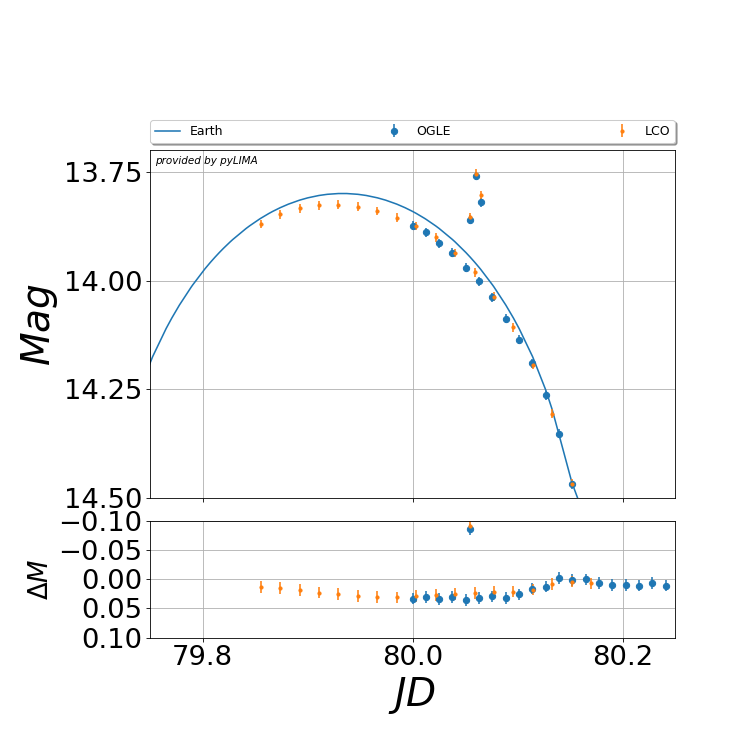

In [ ]:
### Create a plot from lightcurve and best model.
fig_chi2, _ = pyLIMA_plots.plot_lightcurves(fspl, my_fit_chi2.fit_results['best_model'])
### Set the window so the outliers are visible.
fig_chi2.axes[0].set_xlim(79.75, 80.25)
fig_chi2.axes[0].set_ylim(14.50, 13.7)
plt.show()

We now fit the data again but with the **'SOFT_L1'** loss function. This is a **ROBUST LOSS**. 

In [ ]:
### Define the fit.
my_fit_soft_l1 = TRF_fit.TRFfit(fspl, loss_function='soft_l1')

# my_fit_soft_l1.fit_parameters
my_fit_soft_l1.loss_function

'soft_l1'

In [ ]:
### Execute the fitting algorithm.
my_fit_soft_l1.fit()

Selecting OGLE to estimate u0, tE and fs
initial_guess  : Initial parameters guess SUCCESS
Using guess:  [80.09170459757144, 0.010985475158641837, 9.098680017813138, 0.02197128174839425, 2733.4359428865923, 3178.820582140201, 80175.65182837272, 213500.49214330525]
Trust Region Reflective fit SUCCESS
best model:
OrderedDict([('t0', np.float64(79.93109200004932)),
             ('u0', np.float64(0.008142565869637327)),
             ('tE', np.float64(10.097779035856988)),
             ('rho', np.float64(0.02257389531697087)),
             ('fsource_OGLE', np.float64(2922.7655826394357)),
             ('ftotal_OGLE', np.float64(3126.1825698677617)),
             ('fsource_LCO', np.float64(92730.634086057)),
             ('ftotal_LCO', np.float64(141612.10224936853)),
             ('soft_l1', np.float64(2871.290788025437))])


Here we plot the new best model with the lightcurve.

In contrast to the previous fit, the outliers did not noticeably affect the fitted curve.

When using the 'soft_l1' loss, the fit is more robust in regards to possible outliers.

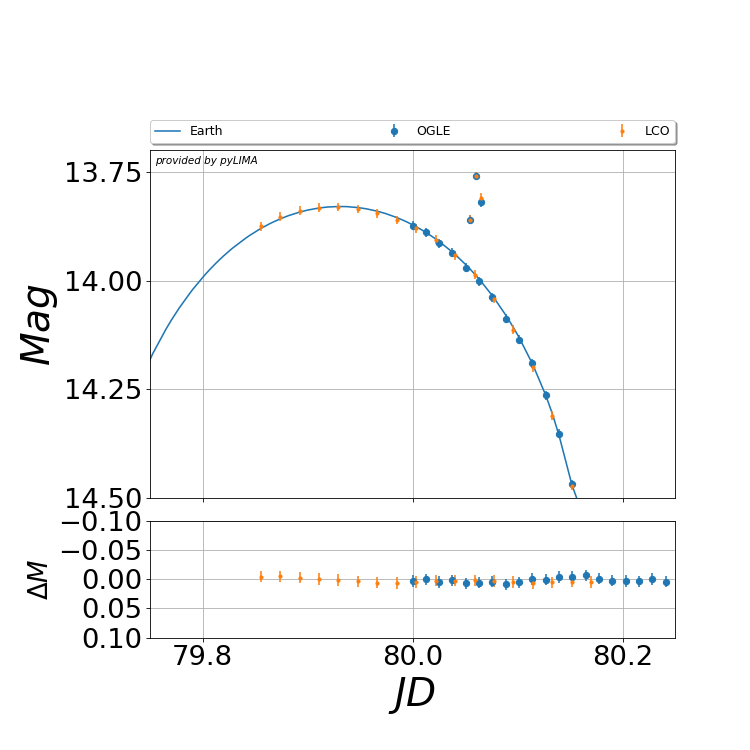

In [ ]:
### Create a plot from lightcurve and best model.
fig_soft_l1, _ = pyLIMA_plots.plot_lightcurves(fspl, my_fit_soft_l1.fit_results['best_model'])
### Set the window so the outliers are visible.
fig_soft_l1.axes[0].set_xlim(79.75, 80.25)
fig_soft_l1.axes[0].set_ylim(14.50, 13.7)
plt.show()

**Let's try the same on the real event OB150966.**

This is a binary lensing event though here we want to fit an PSPL model to the data to infer parameters of the underlying single lensing event.

The data is also used in example 5.

In [ ]:
your_event = event.Event(ra=268.75425, dec=-29.047111111111114)
your_event.name = 'OB150966'

data_1 = np.loadtxt('./data/OGLE_OB150966.dat')
telescope_1 = telescopes.Telescope(name = 'OGLE', 
                                   camera_filter = 'I',
                                   lightcurve = data_1.astype(float),
                                   lightcurve_names = ['time','mag','err_mag'],
                                   lightcurve_units = ['JD','mag','mag'])

data_2 = np.loadtxt('./data/MOA_OB150966.dat')
telescope_2 = telescopes.Telescope(name = 'MOA', 
                                   camera_filter = 'I+R',
                                   lightcurve = data_2.astype(float),
                                   lightcurve_names = ['time','mag','err_mag'],
                                   lightcurve_units = ['JD','mag','mag'])

data_3 = np.loadtxt('./data/SPITZER_OB150966.dat')
telescope_3 = telescopes.Telescope(name = 'SPITZER', 
                                   camera_filter = 'IRAC1',
                                   lightcurve = data_3.astype(float),
                                   lightcurve_names = ['time','mag','err_mag'],
                                   lightcurve_units = ['JD','mag','mag'])

telescope_3.location = 'Space'
telescope_3.spacecraft_name = 'Spitzer'

data_4 = np.loadtxt('./data/DANISH_OB150966.dat')
telescope_4 = telescopes.Telescope(name = 'DANISH', 
                                   camera_filter = 'Z+I',
                                   lightcurve = data_4.astype(float),
                                   lightcurve_names = ['time','mag','err_mag'],
                                   lightcurve_units = ['JD','mag','mag'])

data_5 = np.loadtxt('./data/LCO_CTIO_A_OB150966.dat')
telescope_5 = telescopes.Telescope(name = 'LCO_CTIO_A', 
                                   camera_filter = 'I',
                                   lightcurve = data_5.astype(float),
                                   lightcurve_names = ['time','mag','err_mag'],
                                   lightcurve_units = ['JD','mag','mag'])

data_6 = np.loadtxt('./data/LCO_CTIO_B_OB150966.dat')
telescope_6 = telescopes.Telescope(name = 'LCO_CTIO_B', 
                                   camera_filter = 'I',
                                   lightcurve = data_6.astype(float),
                                   lightcurve_names = ['time','mag','err_mag'],
                                   lightcurve_units = ['JD','mag','mag'])

data_7 = np.loadtxt('./data/LCO_CTIO_OB150966.dat')
telescope_7 = telescopes.Telescope(name = 'LCO_CTIO', 
                                   camera_filter = 'I',
                                   lightcurve = data_7.astype(float),
                                   lightcurve_names = ['time','mag','err_mag'],
                                   lightcurve_units = ['JD','mag','mag'])

data_8 = np.loadtxt('./data/LCO_SAAO_OB150966.dat')
telescope_8 = telescopes.Telescope(name = 'LCO_SAAO', 
                                   camera_filter = 'I',
                                   lightcurve = data_8.astype(float),
                                   lightcurve_names = ['time','mag','err_mag'],
                                   lightcurve_units = ['JD','mag','mag'])

data_9 = np.loadtxt('./data/LCO_SSO_A_OB150966.dat')
telescope_9 = telescopes.Telescope(name = 'LCO_SSO_A', 
                                   camera_filter = 'I',
                                   lightcurve = data_9.astype(float),
                                   lightcurve_names = ['time','mag','err_mag'],
                                   lightcurve_units = ['JD','mag','mag'])

data_10 = np.loadtxt('./data/LCO_SSO_B_OB150966.dat')
telescope_10 = telescopes.Telescope(name = 'LCO_SSO_B', 
                                   camera_filter = 'I',
                                   lightcurve = data_10.astype(float),
                                   lightcurve_names = ['time','mag','err_mag'],
                                   lightcurve_units = ['JD','mag','mag'])

data_11 = np.loadtxt('./data/LCO_SSO_OB150966.dat')
telescope_11 = telescopes.Telescope(name = 'LCO_SSO', 
                                   camera_filter = 'I',
                                   lightcurve = data_11.astype(float),
                                   lightcurve_names = ['time','mag','err_mag'],
                                   lightcurve_units = ['JD','mag','mag'])

your_event.telescopes.append(telescope_1)
your_event.telescopes.append(telescope_2)
your_event.telescopes.append(telescope_3)
your_event.telescopes.append(telescope_4)
your_event.telescopes.append(telescope_5)
your_event.telescopes.append(telescope_6)
your_event.telescopes.append(telescope_7)
your_event.telescopes.append(telescope_8)
your_event.telescopes.append(telescope_9)
your_event.telescopes.append(telescope_10)
your_event.telescopes.append(telescope_11)

your_event.find_survey('OGLE')

your_event.check_event()

check_event  : Everything looks fine...


Parallax(Full) estimated for the telescope OGLE: SUCCESS
Parallax(Full) estimated for the telescope MOA: SUCCESS
Parallax(Full) estimated for the telescope SPITZER: SUCCESS
Parallax(Full) estimated for the telescope DANISH: SUCCESS
Parallax(Full) estimated for the telescope LCO_CTIO_A: SUCCESS
Parallax(Full) estimated for the telescope LCO_CTIO_B: SUCCESS
Parallax(Full) estimated for the telescope LCO_CTIO: SUCCESS
Parallax(Full) estimated for the telescope LCO_SAAO: SUCCESS
Parallax(Full) estimated for the telescope LCO_SSO_A: SUCCESS
Parallax(Full) estimated for the telescope LCO_SSO_B: SUCCESS
Parallax(Full) estimated for the telescope LCO_SSO: SUCCESS
<bound method MLfit.define_parameters of <pyLIMA.fits.TRF_fit.TRFfit object at 0x741d4b50af90>>
Selecting OGLE to estimate u0, tE and fs
initial_guess  : Initial parameters guess SUCCESS
Using guess:  [2457206.471181979, 0.02270303560144297, 58.59963197913021, 0.0, 0.0, 1108.8462288407623, 1304.0254514730027, 1218.4466279290255, 2803.

/home/jakob/miniconda3/envs/microlensing/lib/python3.14/site-packages/pyLIMA/fits/TRF_fit.py:32: RuntimeWarning: divide by zero encountered in log10
  scaling = 10**np.floor(np.log10(np.abs(self.guess)))+1


Trust Region Reflective fit SUCCESS
best model:
OrderedDict([('t0', np.float64(2457205.2663061055)),
             ('u0', np.float64(0.008694057448201878)),
             ('tE', np.float64(69.75660052284265)),
             ('piEN', np.float64(0.016993821642685286)),
             ('piEE', np.float64(-0.1871440790120424)),
             ('fsource_OGLE', np.float64(1034.2898973216884)),
             ('ftotal_OGLE', np.float64(1247.158488723704)),
             ('fsource_MOA', np.float64(1028.6197476333298)),
             ('ftotal_MOA', np.float64(2708.4179040538293)),
             ('fsource_SPITZER', np.float64(3088.4878086111285)),
             ('ftotal_SPITZER', np.float64(11763.12912859907)),
             ('fsource_DANISH', np.float64(1396.4852344477317)),
             ('ftotal_DANISH', np.float64(9370.953142023314)),
             ('fsource_LCO_CTIO_A', np.float64(79.09046303344229)),
             ('ftotal_LCO_CTIO_A', np.float64(7.082385128794708e-33)),
             ('fsource_LCO_CTIO_B',

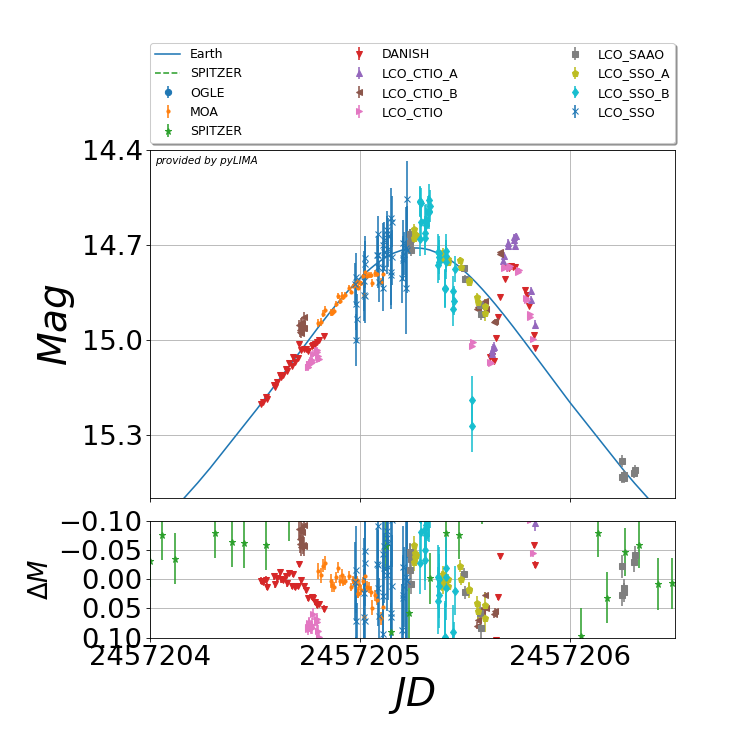

In [ ]:
pspl = PSPL_model.PSPLmodel(your_event, parallax=['Full', 2457205])

### Define the fit.
my_fit_chi2 = TRF_fit.TRFfit(pspl, loss_function='chi2')
print(my_fit_chi2.define_parameters)

### Execute the fitting algorithm.
my_fit_chi2.fit()

### Create a plot from lightcurve and best model.
fig_chi2, _ = pyLIMA_plots.plot_lightcurves(pspl, my_fit_chi2.fit_results['best_model'])
### Set the window so the outliers are visible.
fig_chi2.axes[0].set_xlim(2457204.0, 2457206.5)
fig_chi2.axes[0].set_ylim(15.50, 14.40)
plt.show()

Selecting OGLE to estimate u0, tE and fs
initial_guess  : Initial parameters guess SUCCESS
Using guess:  [2457206.471181979, 0.02270303560144297, 58.59963197913021, 1108.8462288407623, 1304.0254514730027, 1218.4466279290255, 2803.9827053882973, 40592.967806872744, 40984.011849327704, 1967.3725420920525, 10721.53816129697, 289.6998654282122, 4649.317493007159, 1347.1035063156878, 54141.515025684675, 2250.9786964801156, 11316.663456266728, 31.950846919726942, 1559.74644458226, 1858.8913406730408, 1858.8913406730408, 448.6772034809921, 448.6772034809921, 46.56920423138117, 499.6087137190687]
Trust Region Reflective fit SUCCESS
best model:
OrderedDict([('t0', np.float64(2457205.2016398674)),
             ('u0', np.float64(0.01076862225062683)),
             ('tE', np.float64(61.625719430799265)),
             ('fsource_OGLE', np.float64(1207.308106830832)),
             ('ftotal_OGLE', np.float64(1250.7120771553625)),
             ('fsource_MOA', np.float64(1200.7636000211958)),
          

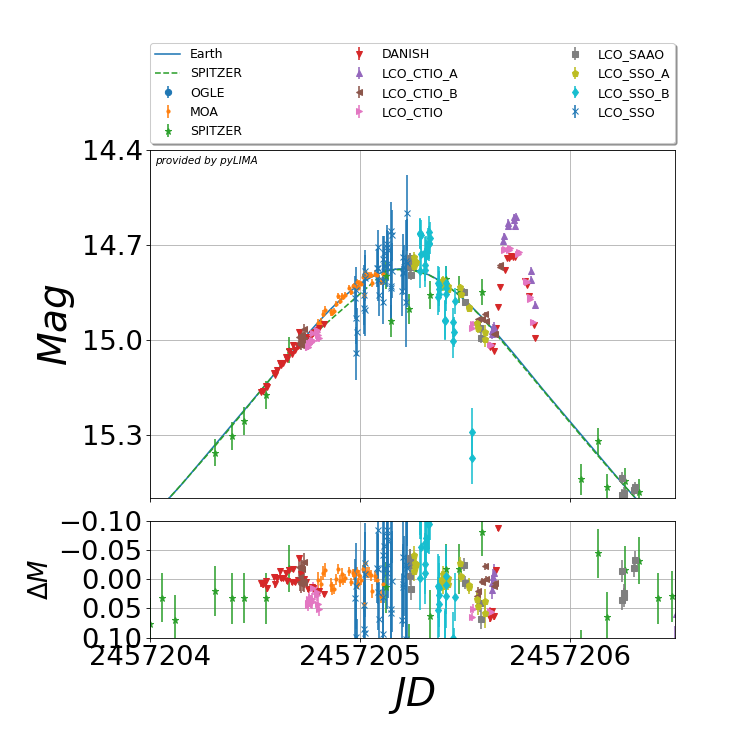

In [ ]:
pspl = PSPL_model.PSPLmodel(your_event)

### Define the fit.
my_fit_chi2 = TRF_fit.TRFfit(pspl, loss_function='soft_l1')

### Execute the fitting algorithm.
my_fit_chi2.fit()

### Create a plot from lightcurve and best model.
fig_chi2, _ = pyLIMA_plots.plot_lightcurves(pspl, my_fit_chi2.fit_results['best_model'])
### Set the window so the outliers are visible.
fig_chi2.axes[0].set_xlim(2457204.0, 2457206.5)
fig_chi2.axes[0].set_ylim(15.50, 14.40)
plt.show()

Similarly to the simulated outliers in the first part, we can also see here that the fit is able to model the single lensing event more accurately when using 'soft_l1' loss. 
The peak from the binary lensing is mostly ignored.

Here we get good tE and u0 approximations for the single lensing event. These can be used as initial guesses for binary lensing model fitting. All other parameters (incl. paralllax) probably converge worse.